## Imports

In [11]:
%matplotlib inline
import os

import matplotlib.pyplot as plt
import numpy as np
import rasterio

import sambuca_core as sbc
from sambuca_core.inversion import InversionParameters, LookUpTable, process_image
from sambuca_core.utility.plotting import plot_siops, find_siops

## Define paths

In [12]:
here = os.getcwd()
input_ = os.path.join(here, 'data', 'input', 'anholt_20170823_b02b09_clipped2.tif')
siop_dir = os.path.join(here, "data", "siops")
output_ = os.path.join(here, 'data', 'output', f"sdb_{os.path.basename(input_)}")
mask_input = os.path.join(os.path.dirname(input_), 'S2_L2A_20180508_B01-B05_ndwi_clipped2.tif')

print(f"{siop_dir = }")
print(f"{input_ = }")
print(f"{mask_input = }")

siop_dir = 'D:\\Projects\\work\\sambuca_core_remastered\\data\\siops'
input_ = 'D:\\Projects\\work\\sambuca_core_remastered\\data\\input\\anholt_20170823_b02b09_clipped2.tif'
mask_input = 'D:\\Projects\\work\\sambuca_core_remastered\\data\\input\\S2_L2A_20180508_B01-B05_ndwi_clipped2.tif'


## Load image

In [13]:
with rasterio.open(input_) as src:
    # Read all bands
    image_int16 = src.read()
    metadata = src.meta

    if metadata['dtype'] == 'float32':
        scaling_factor = 1.0
    else:
        scaling_factor = 10000.0
    print(f"{scaling_factor = }")
    surface_reflectance = image_int16.astype(np.float32) / scaling_factor
    no_data_mask = (image_int16 <= 0)
    surface_reflectance[no_data_mask] = np.nan
    rrs = surface_reflectance / np.pi
    rrs[rrs < 0] = 0
    rrs_image = np.transpose(rrs, (1, 2, 0))

if mask_input is not None and mask_input != '':
    with rasterio.open(mask_input) as src:
        mask_image = src.read()
        data_mask = (mask_image[2, ...] > 0.75)
else:
    data_mask = np.ones_like(rrs_image[..., 0], dtype=bool)

scaling_factor = 1.0


## Load SIOPs

Available SIOPs:
  absorption:
    - cdom_absorption.csv
    - nap_absorption.csv
    - phytoplankton_absorption.csv
    - water_absorption.csv
  backscatter:
    - nap_backscatter.csv
    - phytoplankton_backscatter.csv
    - water_backscatter.csv
  substrates:
    - coral_substrate.csv
    - sand_substrate.csv
    - seagrass_substrate.csv
Figure saved to absorption_siops.png


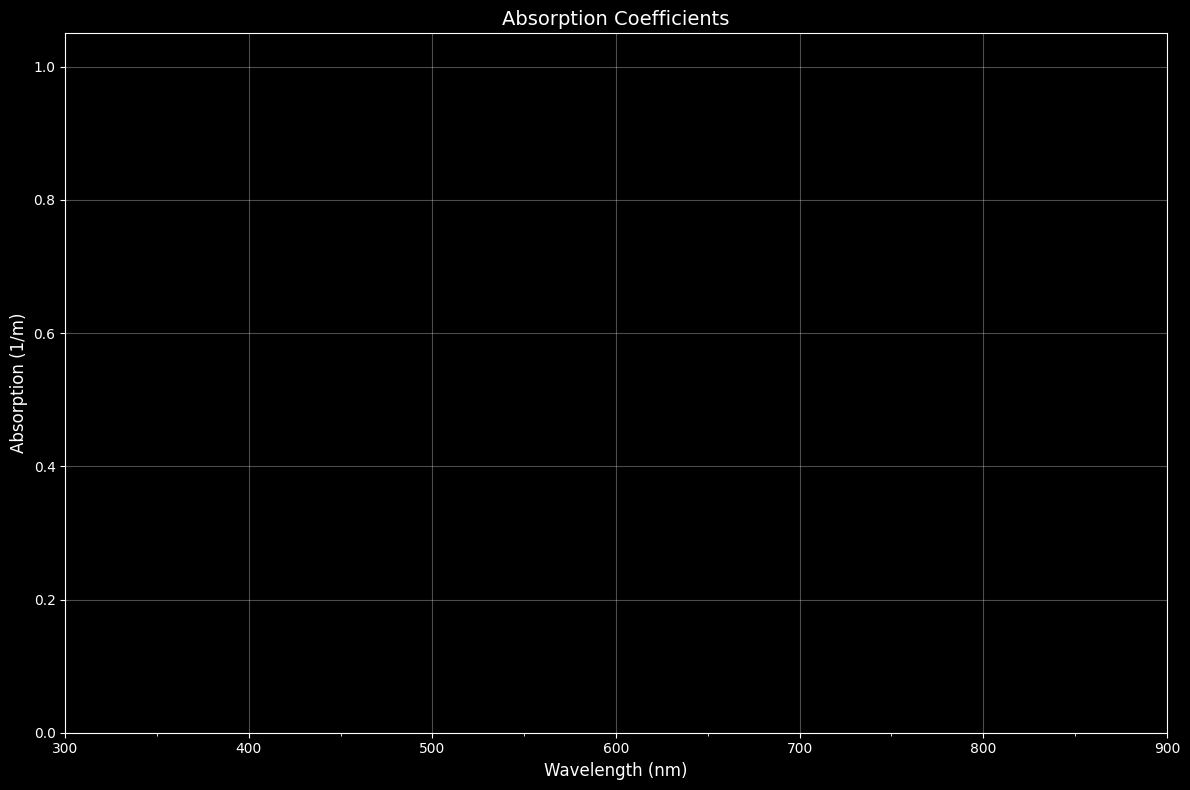

Figure saved to backscatter_siops.png


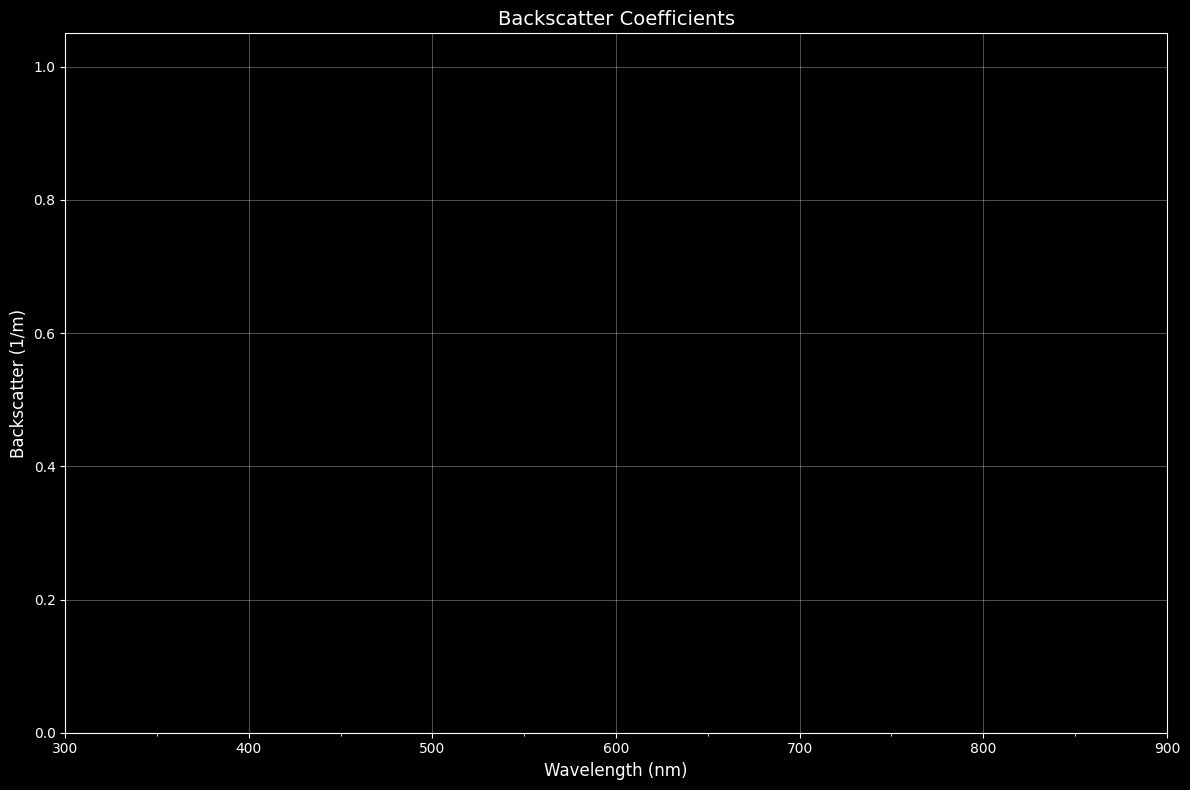

Figure saved to substrate_siops.png


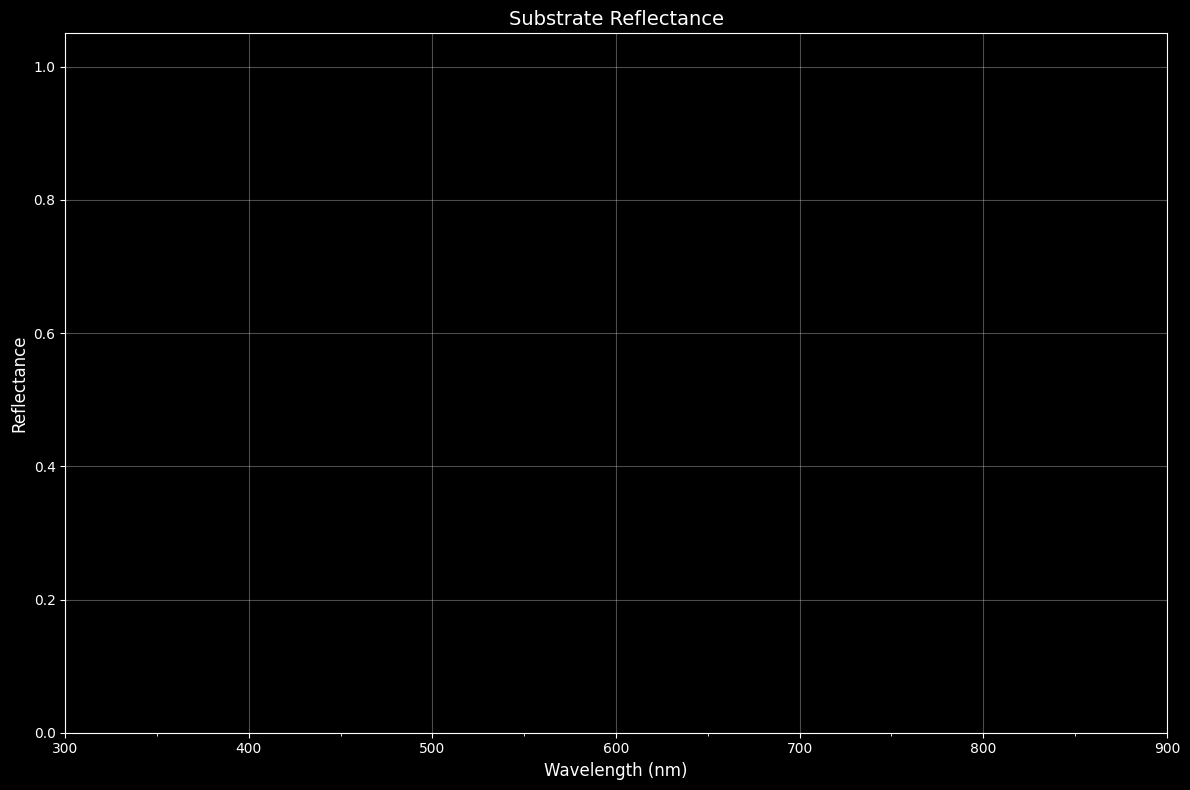

In [14]:
# List and categorize available SIOPs
categories = find_siops(siop_dir)
save_ = True
# Print available SIOPs by category
print("Available SIOPs:")
for category, files in categories.items():
    if files:
        print(f"  {category}:")
        for file in files:
            print(f"    - {file}")

# Example 1: Plot all absorption SIOPs
if categories['absorption']:
    plot_siops(categories['absorption'], siop_dir,
              output_file="absorption_siops.png" if save_ else None,
              title="Absorption Coefficients",
              y_label="Absorption (1/m)")

# Example 2: Plot all backscatter SIOPs
if categories['backscatter']:
    plot_siops(categories['backscatter'], siop_dir,
              output_file="backscatter_siops.png" if save_ else None,
              title="Backscatter Coefficients",
              y_label="Backscatter (1/m)")

# Example 3: Plot all substrate SIOPs
if categories['substrates']:
    plot_siops(categories['substrates'], siop_dir,
              output_file="substrate_siops.png" if save_ else None,
              title="Substrate Reflectance",
              y_label="Reflectance")